# Are elevated lactate levels associated with ICU mortality?

**Author:** Johanna Albers  
**Date:** March 2026

## Project overview

**Research Question:** Are elevated lactate levels associated with ICU mortality?  

**Study Design:** Retrospective cohort study using MIMIC-III database  

**Primary Analysis:** Association between first lactate measurement post-ICU admission and in-hospital mortality.

### Data Description

This study uses data from the MIMIC-III database. The unit of analysis is the **ICU stay**. For each stay, the **first lactate measurement within 24 hours after ICU admission** was extracted. The primary outcome is **ICU mortality**.

In [ ]:
# ! pip install numpy matplotlib seaborn scipy statsmodels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

## Data loading

Load the cohort from CSV. The file `cohort_export.csv` is produced by the **icu-lactate-data-extraction** notebook (run that notebook first to extract data from the MIMIC-III database).

In [3]:
initial_df = pd.read_csv('cohort_export.csv')
initial_df.info()

In [ ]:
initial_df.head()

In [5]:
print("Analysis cohort:", initial_df.shape[0])

Analysis cohort: 22307


### Dataset structure

The cohort contains ICU stays extracted from the MIMIC-III database.  
Each row represents a single ICU stay with information on demographics, ICU admission and discharge times, mortality outcomes, and the first lactate measurement recorded within 24 hours after ICU admission.

The dataset initially contains **22,307 ICU stays** with **17 variables** including patient characteristics, identifiers, and lactate measurements.

## Data cleaning

Check for duplicates (none expected). Then inspect null values.

In [6]:
print('Duplicates:', initial_df.duplicated().sum())

Duplicates: 0


In [ ]:
null_counts = initial_df.isna().sum()
null_counts[null_counts > 0].sort_values(ascending=False)

### Data quality checks

The dataset was inspected for duplicate observations and missing values.

- No duplicate ICU stays were detected.
- Only a small number of lactate measurements were missing or non-numeric.
- The `lactate_flag` variable contains many missing values but is not required for the analysis.

These checks confirm that the dataset is suitable for further cleaning and analysis.

Keep observations with lactate > 0 mmol/L; ensure numeric lactate; handle ">" or "GREATER THAN" by assigning 31.

In [ ]:
def parse_lactate(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().upper()
    if '>' in str(val) or 'GREATER THAN' in s:
        return 31.0
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

clean_values_df = initial_df.copy()
clean_values_df['lactate_value_num'] = clean_values_df['lactate_value'].apply(parse_lactate)
clean_values_df = clean_values_df.dropna(subset=['lactate_value_num'])

suspicious = clean_values_df[(clean_values_df['lactate_value_num'] <= 0) | (clean_values_df['lactate_value_num'] > 31)]
print('Suspicious lactate values (<=0 or >31):', len(suspicious))
suspicious

In [9]:
print('ICU dead but hospital not dead:', ((clean_values_df['icu_dead'] == 1) & (clean_values_df['hospital_dead'] == 0)).sum())

ICU dead but hospital not dead: 0


In [ ]:
death_counts = (
    clean_values_df.groupby('subject_id')
    .apply(lambda g: pd.Series({
        'hosp_dead': g.loc[g['hospital_dead'] == 1, 'hadm_id'].nunique(),
        'icu_dead': g.loc[g['icu_dead'] == 1, 'icustay_id'].nunique()
    }))
)
death_counts = death_counts[death_counts['icu_dead'] > 1]
death_counts

In [11]:
# Some patients have more than one ICU stay flagged as an ICU death within the
# same hospital admission. Keep the flag only on the last ICU stay of each
# admission so that each death is counted exactly once (no hardcoded IDs).
clean_values_df = clean_values_df.copy()
last_stay = (
    clean_values_df.sort_values("outtime")
    .groupby(["subject_id", "hadm_id"])["icustay_id"]
    .transform("last")
)
dup_death = (clean_values_df["icu_dead"] == 1) & (clean_values_df["icustay_id"] != last_stay)
clean_values_df.loc[dup_death, ["hospital_dead", "icu_dead"]] = 0
print("Duplicate ICU-death flags reset:", int(dup_death.sum()))


In [ ]:
clean_values_df = clean_values_df[[
    'icustay_id', 'age_icu_exit', 'gender', 'icu_dead', 'lactate_value_num'
]]
clean_values_df.head()

In [13]:
clean_values_df.describe(include='all')

,icustay_id,age_icu_exit,gender,icu_dead,lactate_value_num
count,22302.000000,22302.000000,22302,22302.000000,22302.000000
unique,NaN,NaN,2,NaN,NaN
top,NaN,NaN,M,NaN,NaN
freq,NaN,NaN,12806,NaN,NaN
mean,249906.394763,74.088557,NaN,0.159806,2.436472
std,28878.142896,52.551029,NaN,0.366435,2.045538
min,200001.000000,0.000000,NaN,0.000000,0.300000
25%,224940.500000,54.000000,NaN,0.000000,1.200000
50%,249918.000000,66.000000,NaN,0.000000,1.800000
75%,275104.500000,78.000000,NaN,0.000000,2.900000


In [14]:
# MIMIC-III: ages 89+ are shifted; cap at 90 for analysis
clean_values_df = clean_values_df.copy()
clean_values_df['age_icu_exit'] = clean_values_df['age_icu_exit'].clip(upper=90)

In [ ]:
eda_df = clean_values_df.copy()
eda_df.head()

### Cleaning lactate measurements

Lactate values were standardized to ensure consistent numeric representation.

- Non-numeric values were parsed and converted to numeric form.
- Measurements reported as ">X" or "GREATER THAN" were interpreted as the upper measurable limit (31 mmol/L).
- Observations with missing lactate values were removed.

After cleaning, all remaining observations contain valid numeric lactate measurements suitable for analysis.

# Exploratory analysis

In [16]:
print('Shape:', eda_df.shape)
eda_df.describe(include='all')

Shape: (22302, 5)


,icustay_id,age_icu_exit,gender,icu_dead,lactate_value_num
count,22302.000000,22302.000000,22302,22302.000000,22302.000000
unique,NaN,NaN,2,NaN,NaN
top,NaN,NaN,M,NaN,NaN
freq,NaN,NaN,12806,NaN,NaN
mean,249906.394763,64.274370,NaN,0.159806,2.436472
std,28878.142896,16.889951,NaN,0.366435,2.045538
min,200001.000000,0.000000,NaN,0.000000,0.300000
25%,224940.500000,54.000000,NaN,0.000000,1.200000
50%,249918.000000,66.000000,NaN,0.000000,1.800000
75%,275104.500000,78.000000,NaN,0.000000,2.900000


In [17]:
print(eda_df['gender'].value_counts())
print()
print(clean_values_df['icu_dead'].value_counts())
print()
print(clean_values_df['icu_dead'].value_counts(normalize=True).mul(100).round(2))

gender
M    12806
F     9496
Name: count, dtype: int64

icu_dead
0    18738
1     3564
Name: count, dtype: int64

icu_dead
0    84.02
1    15.98
Name: proportion, dtype: float64


### Descriptive statistics

The cleaned cohort contains **22,302 ICU stays**.

Key observations:
- The mean lactate level is approximately **2.44 mmol/L**.
- ICU mortality occurred in **15.98%** of stays.
- The cohort includes both male and female patients, with males representing the majority.

These descriptive statistics provide an overview of the patient population included in the analysis.

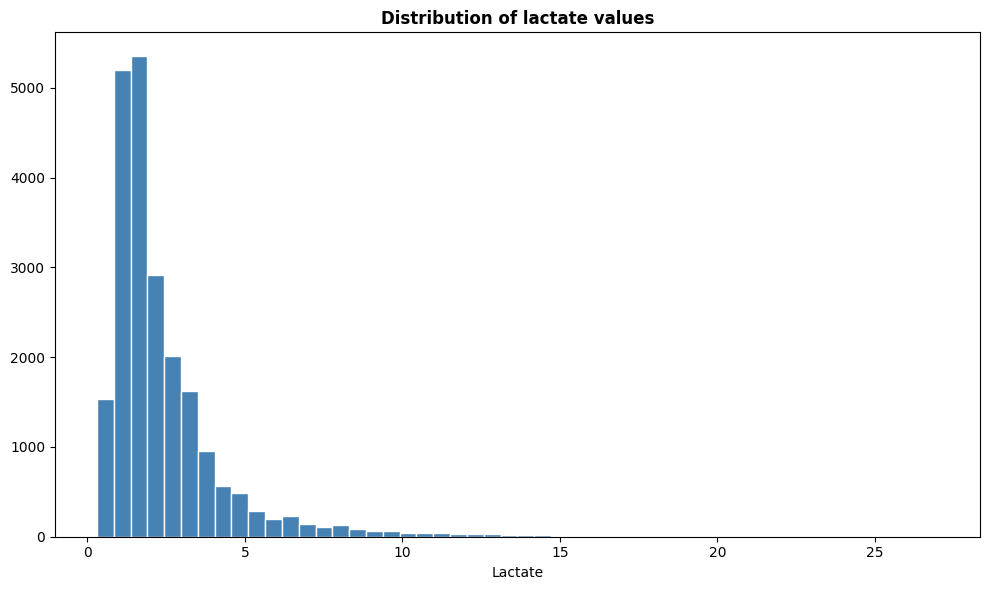

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(eda_df['lactate_value_num'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of lactate values', fontsize=12, fontweight='bold')
ax.set_xlabel('Lactate')
plt.tight_layout()
plt.show()

### Distribution of lactate values

The histogram shows that lactate levels are **right-skewed**, with most observations at lower values and a small number of very high measurements.

Such skewness is common for laboratory biomarkers in clinical datasets.  
To improve model stability and interpretability, lactate values are **log-transformed** before inclusion in the regression model.

In [19]:
eda_df = eda_df.copy()
eda_df['log_lactate'] = np.log(eda_df['lactate_value_num'])

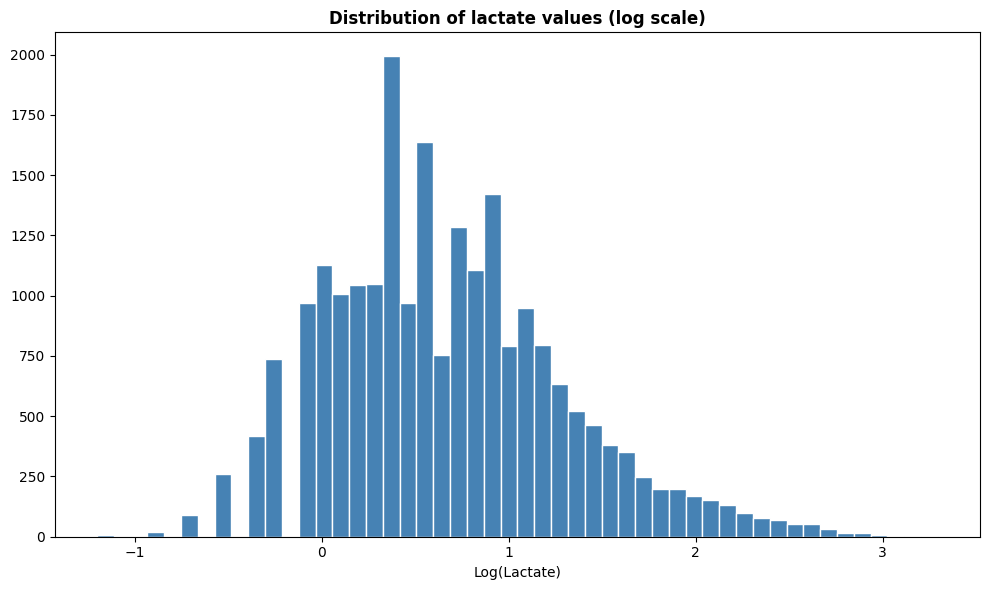

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(eda_df['log_lactate'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of lactate values (log scale)', fontsize=12, fontweight='bold')
ax.set_xlabel('Log(Lactate)')
plt.tight_layout()
plt.show()

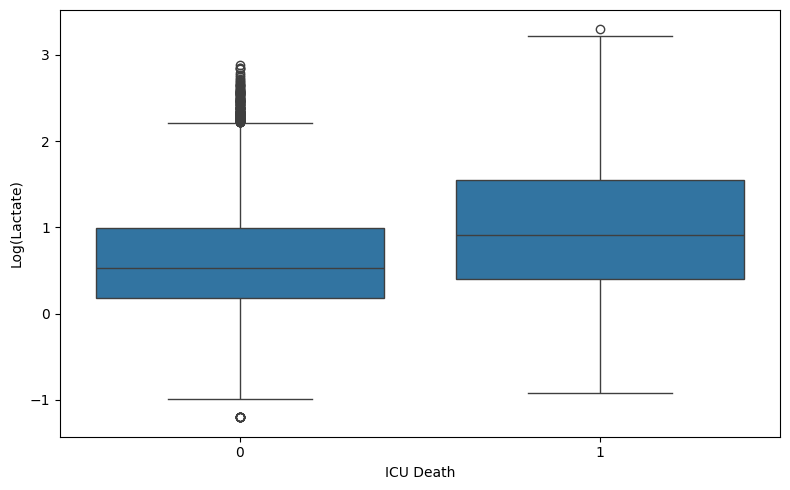

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=eda_df, x='icu_dead', y='log_lactate', ax=ax)
ax.set_xlabel('ICU Death')
ax.set_ylabel('Log(Lactate)')
plt.tight_layout()
plt.show()

### Lactate levels and ICU mortality

The boxplot suggests that patients who died during the ICU stay tend to have **higher lactate levels** compared to survivors.

This visual pattern indicates a potential association between elevated lactate levels and ICU mortality, which will be formally tested using logistic regression.

# Statistical Analysis

Define *analysis_df* and fit the main logistic regression: ICU death ~ log_lactate + age_icu_exit + gender.

In [ ]:
analysis_df = eda_df[[
    'icustay_id', 'age_icu_exit', 'gender', 'icu_dead',
    'log_lactate'
]].copy()
analysis_df.head()

In [23]:
print("Final analysis cohort:", analysis_df.shape[0])

Final analysis cohort: 22302


## Fit the model

In [24]:
df = analysis_df.dropna(subset=['icu_dead', 'log_lactate', 'age_icu_exit', 'gender']).reset_index(drop=True)
df['gender'] = pd.Categorical(df['gender'])
X = sm.add_constant(pd.get_dummies(df[['log_lactate', 'age_icu_exit', 'gender']], drop_first=True)).astype(np.float64)
y = np.asarray(df['icu_dead'].astype(int), dtype=np.float64)

model_main = Logit(y, X).fit()
print(model_main.summary())

Optimization terminated successfully.
         Current function value: 0.402644
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                22302
Model:                          Logit   Df Residuals:                    22298
Method:                           MLE   Df Model:                            3
Date:                Sun, 08 Mar 2026   Pseudo R-squ.:                 0.08354
Time:                        09:54:14   Log-Likelihood:                -8979.8
converged:                       True   LL-Null:                       -9798.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -4.0182      0.097    -41.308      0.000      -4.209      -3.828
log_lactate      1.0375

The model explained a modest proportion of outcome variability (Pseudo R² = 0.083).

## Odds Ratios with 95% CI

In [25]:
conf = model_main.conf_int()
conf.columns = ['2.5%', '97.5%']
or_ci = pd.DataFrame({
    'OR': np.exp(model_main.params),
    '2.5%': np.exp(conf['2.5%']),
    '97.5%': np.exp(conf['97.5%'])
})
print(or_ci)
print()


                    OR      2.5%     97.5%
const         0.017986  0.014864  0.021763
log_lactate   2.822118  2.663269  2.990442
age_icu_exit  1.023580  1.021100  1.026066
gender_M      0.973414  0.902367  1.050056



### Odds ratios

To improve interpretability, regression coefficients were exponentiated to obtain **odds ratios (ORs)**.

- An OR > 1 indicates increased odds of ICU mortality.
- An OR < 1 indicates decreased odds.
- Confidence intervals that include 1 indicate a non-significant association.

These results will be used as structured input for the language model in the next step.


### Preparing results for AI interpretation

The statistical results are converted into a structured table containing:

- predictor variable
- odds ratio
- confidence intervals
- p-value
- model type
- sample size

This structured representation allows the results to be passed to a large language model (LLM), which automatically generates a clinically interpretable summary of the statistical findings.

In [26]:
ci = model_main.conf_int()
results_llm = pd.DataFrame({
    'variable': model_main.params.index.tolist(),
    'outcome': 'ICU death',
    'odds_ratio': np.exp(model_main.params).tolist(),
    'confidence_interval_lower': np.exp(ci[0]).tolist(),
    'confidence_interval_upper': np.exp(ci[1]).tolist(),
    'p_value': model_main.pvalues.tolist(),
    'sample_size': int(model_main.nobs),
    'model_type': 'Logistic regression'
})
print(results_llm)

#Export as .csv
results_llm.to_csv('icu_lactate_logistic_model_results.csv', index=False)


       variable    outcome  odds_ratio  confidence_interval_lower  \
0         const  ICU death    0.017986                   0.014864   
1   log_lactate  ICU death    2.822118                   2.663269   
2  age_icu_exit  ICU death    1.023580                   1.021100   
3      gender_M  ICU death    0.973414                   0.902367   

   confidence_interval_upper        p_value  sample_size           model_type  
0                   0.021763   0.000000e+00        22302  Logistic regression  
1                   2.990442  6.849880e-270        22302  Logistic regression  
2                   1.026066   4.245777e-79        22302  Logistic regression  
3                   1.050056   4.859084e-01        22302  Logistic regression  


Inserting the results into the prompt for the LLM:

In [27]:
prompt = """You are a clinical data scientist interpreting statistical results from a medical study.

Task: Write a clear, professional interpretation of the results of a **multivariable logistic regression model** in plain scientific English, similar to the style used in clinical research papers.

Context of the study:

* Outcome: {OUTCOME}
* Model: {MODEL_TYPE}
* Predictors included in the model: {PREDICTORS}
* The model adjusts for all listed predictors simultaneously.
* Sample size: {SAMPLE_SIZE} ICU stays

Statistical results (input):

Variable | OR | CI_lower | CI_upper | p_value
{MODEL_RESULTS_TABLE}

Instructions for interpretation:

1. Start with a short introductory sentence explaining that a multivariable logistic regression model was used to assess the association between the predictors and ICU mortality.
2. Mention the sample size.
3. Interpret each variable in separate sentences or short paragraphs.
4. For each variable:

   * Report the odds ratio (OR), 95% confidence interval, and p-value.
   * Explain whether the association increases or decreases the odds of mortality.
5. Interpret statistical significance:

   * If the 95% CI includes 1 or p ≥ 0.05, state that the association is not statistically significant.
6. Avoid causal language. Use phrases like "associated with".
7. End with a short overall conclusion summarizing the key finding.

Writing style:

* Professional clinical research style
* Clear and concise
* Similar to the results section of a medical paper
* Do not use bullet points
* Write in paragraph form

Generate the interpretation based on the provided model results.
"""

# Insert statistical results and context from results_llm into the prompt (run the results_llm cell first)
model_results_table = results_llm[["variable", "odds_ratio", "confidence_interval_lower", "confidence_interval_upper", "p_value"]].to_string(index=False)
sample_size = int(results_llm["sample_size"].iloc[0])
outcome = results_llm["outcome"].iloc[0]
model_type = results_llm["model_type"].iloc[0]
predictors = ", ".join(results_llm[results_llm["variable"] != "const"]["variable"].tolist())
prompt_with_results = prompt.format(
    MODEL_RESULTS_TABLE=model_results_table,
    SAMPLE_SIZE=sample_size,
    OUTCOME=outcome,
    MODEL_TYPE=model_type,
    PREDICTORS=predictors,
)

print(prompt_with_results)

You are a clinical data scientist interpreting statistical results from a medical study.

Task: Write a clear, professional interpretation of the results of a **multivariable logistic regression model** in plain scientific English, similar to the style used in clinical research papers.

Context of the study:

* Outcome: ICU death
* Model: Logistic regression
* Predictors included in the model: log_lactate, age_icu_exit, gender_M
* The model adjusts for all listed predictors simultaneously.
* Sample size: 22302 ICU stays

Statistical results (input):

Variable | OR | CI_lower | CI_upper | p_value
    variable  odds_ratio  confidence_interval_lower  confidence_interval_upper       p_value
       const    0.017986                   0.014864                   0.021763  0.000000e+00
 log_lactate    2.822118                   2.663269                   2.990442 6.849880e-270
age_icu_exit    1.023580                   1.021100                   1.026066  4.245777e-79
    gender_M    0.973414 

## Send results to GPT-4.1 for interpretation (requires `openai` and `OPENAI_API_KEY`).


### Data Privacy and Safety

This project does **not use or expose any patient-level data**.  
Only **aggregated statistical results** from the analysis are used as input for the LLM.

The information sent to the model consists exclusively of:
- model type (logistic regression)
- variables
- odds ratios (OR)
- confidence intervals (CI)
- p-values
- sample size

These are **summary statistics** and contain **no personally identifiable information (PII)** or patient records.


Therefore, the LLM only processes **statistical outputs**, making the workflow **safe with respect to patient privacy and data protection**.

In [ ]:
! pip install openai

In [ ]:
pip install python-dotenv

In [30]:
from openai import OpenAI
import os
from dotenv import load_dotenv


load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError(
        "OpenAI API key not found. Set it by either:\n"
        "  1. In terminal before starting Jupyter: export OPENAI_API_KEY='sk-...'\n"
        "  2. In a cell above: os.environ['OPENAI_API_KEY'] = 'sk-...'\n"
        "  3. Or uncomment and set the key in the two lines above this block."
    )
client = OpenAI(api_key=api_key)

In [32]:
# Send prompt_with_results to the LLM (requires client and prompt_with_results from cells above)
from openai import RateLimitError, APIError

try:
    response = client.chat.completions.create(
        model="gpt-4.1",
        messages=[{"role": "user", "content": prompt_with_results}],
    )
    interpretation_text = f'''Interpretation of statistical results:

{response.choices[0].message.content}
'''
    print(interpretation_text)
    output_path = 'interpretation_results.txt'
    with open(output_path, 'w') as f:
        f.write(interpretation_text)
    print(f'\nSaved to {output_path}')
except RateLimitError as e:
    if "insufficient_quota" in str(e).lower() or "429" in str(e):
        print("OpenAI quota exceeded (429). Add payment or check billing: https://platform.openai.com/account/billing")
    else:
        print("Rate limit hit. Wait a minute and try again.")
except APIError as e:
    print(f"OpenAI API error: {e}")


Interpretation of statistical results:

A multivariable logistic regression model was used to assess the association between log-transformed lactate, age at ICU discharge, and gender with ICU mortality, adjusting for all predictors simultaneously. The analysis included a total of 22,302 ICU stays.

Higher log-transformed lactate levels were strongly associated with increased odds of ICU mortality (odds ratio [OR] 2.82, 95% confidence interval [CI] 2.66–2.99, p < 0.001). This indicates that, holding other variables constant, an increase in log-lactate was associated with substantially higher odds of death in the ICU. Additionally, older age at ICU discharge was also significantly associated with increased odds of mortality (OR 1.02 per year, 95% CI 1.02–1.03, p < 0.001), suggesting that each additional year of age at ICU exit was linked to a modest increase in the odds of ICU death.

Male gender was not significantly associated with ICU mortality in this model (OR 0.97, 95% CI 0.90–1.05

### AI-generated interpretation

The regression results were sent to a large language model (GPT-4.1) to automatically generate a clinical interpretation of the statistical findings.

The model translates technical statistical outputs (odds ratios, confidence intervals, and p-values) into clear scientific language similar to that used in clinical research publications.